<a href="https://www.kaggle.com/code/avikdas567/nuclear-power-and-the-global-energy-transition?scriptVersionId=324111218" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Nuclear Power, Decarbonisation, and the Global Energy Transition (1965–2025)

Nuclear energy has played very different roles across countries. Some economies built large nuclear fleets and achieved low-carbon electricity systems, while others moved toward renewables or remained dependent on fossil fuels.

Using 60 years of data across 195 countries, this notebook examines how nuclear generation evolved, how it interacts with renewable energy deployment, and how strongly energy mix choices influence electricity-sector carbon intensity.

The analysis combines energy system metrics, decarbonisation indicators, macroeconomic variables, clustering techniques, and machine learning to identify the major drivers behind low-carbon electricity systems.


In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")

DATA_PATH = "/kaggle/input/datasets/kanchana1990/global-nuclear-energy-intelligence/global_nuclear_energy_intelligence_1965_2025.csv"


In [2]:

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (15045, 54)


,country,iso_code,year,population,gdp,nuclear_electricity,nuclear_share_elec,nuclear_share_energy,nuclear_consumption,nuclear_elec_per_capita,...,nuclear_dependency_tier,decarbonisation_score,is_low_carbon_majority,nuclear_vs_renewables_twh,renewables_overtook_nuclear,carbon_intensity_tier,last_nuclear_year,is_phase_out_country,decade,energy_mix_diversity
0,ASEAN (Ember),NaN,2000,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,Nuclear-Free,19.33,0,-73.23,0,High,NaN,0,2000,3
1,ASEAN (Ember),NaN,2001,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,Nuclear-Free,19.06,0,-77.19,0,High,NaN,0,2000,3
2,ASEAN (Ember),NaN,2002,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,Nuclear-Free,17.67,0,-76.53,0,High,NaN,0,2000,3
3,ASEAN (Ember),NaN,2003,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,Nuclear-Free,16.67,0,-76.39,0,High,NaN,0,2000,3
4,ASEAN (Ember),NaN,2004,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,Nuclear-Free,15.70,0,-77.95,0,High,NaN,0,2000,3



## Data Audit

The dataset documentation states that only sovereign countries should be present. A quick inspection reveals several regional aggregates and historical entities. These are useful for some analyses but can distort country-level modeling.

For country-focused analysis, records without ISO codes are removed.


In [3]:

raw_shape = df.shape

df = df[df["iso_code"].notna()].copy()

print("Original:", raw_shape)
print("Country-only:", df.shape)

missing = (df.isna().mean()*100).sort_values(ascending=False)
display(missing.head(20))


Original: (15045, 54)
Country-only: (11285, 54)


nuclear_cons_change_pct      86.858662
last_nuclear_year            81.772264
greenhouse_gas_emissions     52.264067
co2_mtonne                   52.264067
nuclear_cons_change_twh      49.038547
wb_nuclear_share_elec_pct    47.975188
gas_share_elec               47.868852
gas_electricity              47.638458
coal_share_elec              47.000443
coal_electricity             46.770049
fossil_share_elec            46.247231
fossil_electricity           46.016837
wind_share_elec              43.774922
solar_share_elec             42.108994
low_carbon_share_elec        41.949490
wind_electricity             31.847585
hydro_electricity            30.863979
energy_per_gdp               30.731059
solar_electricity            30.181657
low_carbon_electricity       30.022153
dtype: float64

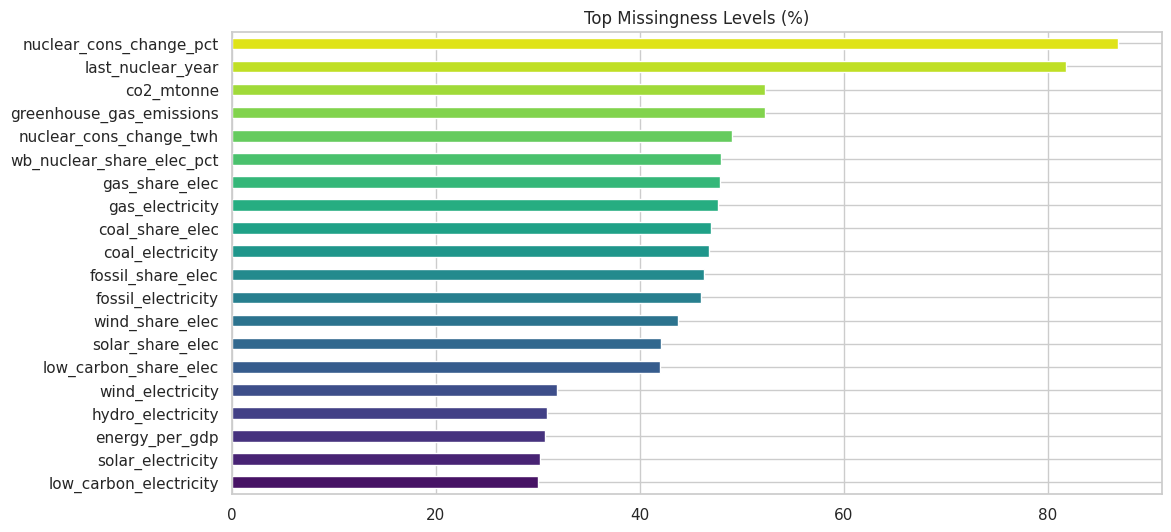

In [4]:

palette = "mako"

plt.figure(figsize=(12,6))
missing.head(20).sort_values().plot(kind="barh", color=sns.color_palette("viridis",20))
plt.title("Top Missingness Levels (%)")
plt.show()


### Observations

- Roughly one quarter of the original records correspond to regional aggregates or entities without ISO country codes.
- Missingness is concentrated in macroeconomic and legacy energy variables rather than the core nuclear metrics.
- Nuclear generation fields are largely complete because non-nuclear countries were intentionally recorded as zero rather than missing.
- The dataset is suitable for longitudinal analysis without extensive cleaning.


## Data Cleaning Strategy

The dataset is already highly structured, with consistent country-year records and well-defined energy indicators. As a result, only minimal cleaning is required before analysis.

The following steps were applied:

1. Remove aggregate entities and regional groupings that do not have valid ISO country codes.
2. Preserve missing macroeconomic variables rather than introducing broad imputations during exploratory analysis.
3. Apply median imputation only within machine learning workflows where complete feature matrices are required.
4. Retain zero nuclear generation values, as they represent countries without active nuclear electricity production rather than missing data.

These choices help preserve the original signal while avoiding unnecessary transformations.

In [5]:

numeric_cols = df.select_dtypes(include=np.number).columns

summary = df[numeric_cols].describe().T
display(summary.head())


,count,mean,std,min,25%,50%,75%,max
year,11285.0,1.998261e+03,1.615883e+01,1965.0,1.986000e+03,1.999000e+03,2.012000e+03,2.025000e+03
population,11227.0,3.041322e+07,1.185101e+08,1776.0,7.239975e+05,5.720413e+06,1.929211e+07,1.463866e+09
gdp,8315.0,3.983406e+11,1.440659e+12,164206000.0,1.578342e+10,5.493734e+10,2.297636e+11,2.696602e+13
nuclear_electricity,11285.0,9.526448e+00,5.594571e+01,0.0,0.000000e+00,0.000000e+00,0.000000e+00,8.094100e+02
nuclear_share_elec,11285.0,2.807787e+00,1.036263e+01,0.0,0.000000e+00,0.000000e+00,0.000000e+00,8.801100e+01


## Global Nuclear Trend

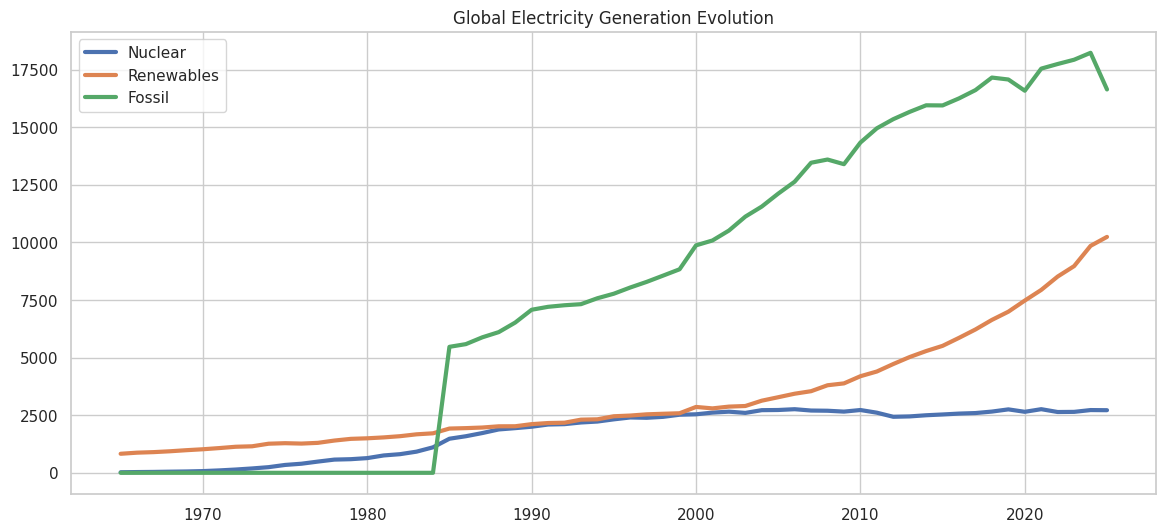

In [6]:

annual = df.groupby("year").agg({
    "nuclear_electricity":"sum",
    "renewables_electricity":"sum",
    "fossil_electricity":"sum"
}).reset_index()

plt.figure(figsize=(14,6))
plt.plot(annual.year, annual.nuclear_electricity, linewidth=3, label="Nuclear")
plt.plot(annual.year, annual.renewables_electricity, linewidth=3, label="Renewables")
plt.plot(annual.year, annual.fossil_electricity, linewidth=3, label="Fossil")
plt.legend()
plt.title("Global Electricity Generation Evolution")
plt.show()


### Analysis

The long-run trend chart shows a clear structural shift in the global electricity mix.

- Fossil fuels remain the dominant source of electricity generation across the period.
- Nuclear generation expanded rapidly during the late twentieth century and then entered a more mature growth phase.
- Renewable electricity accelerates sharply in the most recent decades, reflecting large-scale deployment of wind and solar technologies.
- The energy transition appears additive rather than purely substitutional, with multiple low-carbon technologies expanding simultaneously.


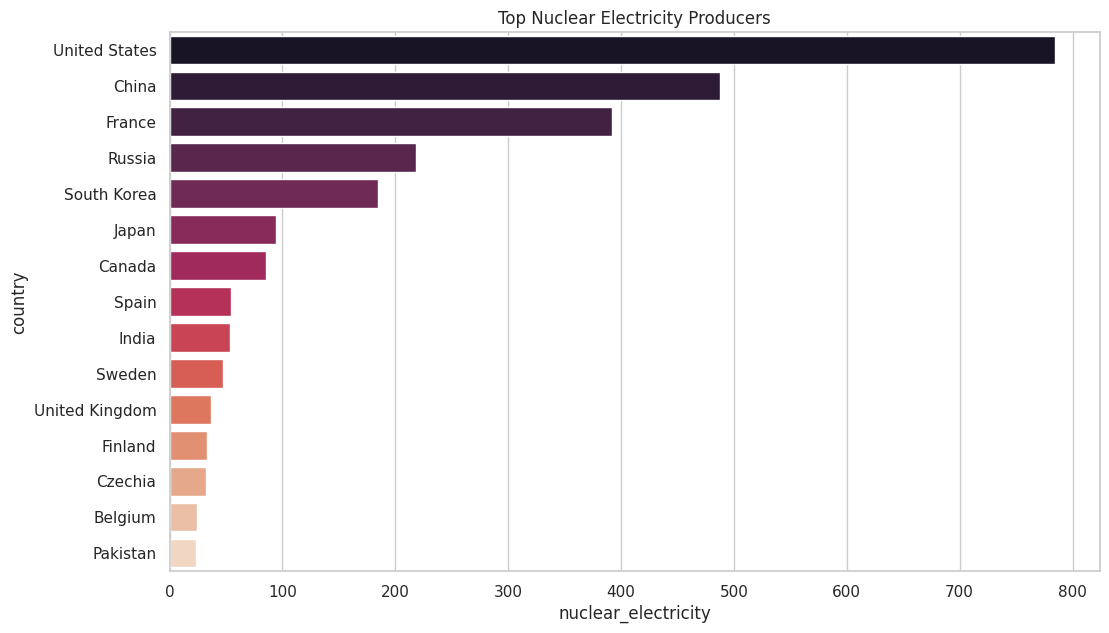

In [7]:

latest = df[df.year == df.year.max()]

top_nuclear = latest.nlargest(15, "nuclear_electricity")

plt.figure(figsize=(12,7))
sns.barplot(data=top_nuclear, y="country", x="nuclear_electricity", palette="rocket")
plt.title("Top Nuclear Electricity Producers")
plt.show()


### Analysis

The latest-year ranking is highly concentrated.

- A relatively small group of countries accounts for a large share of global nuclear generation.
- Established nuclear programs continue to dominate production.
- Nuclear generation remains geographically concentrated compared with renewables, which have spread more broadly across countries.


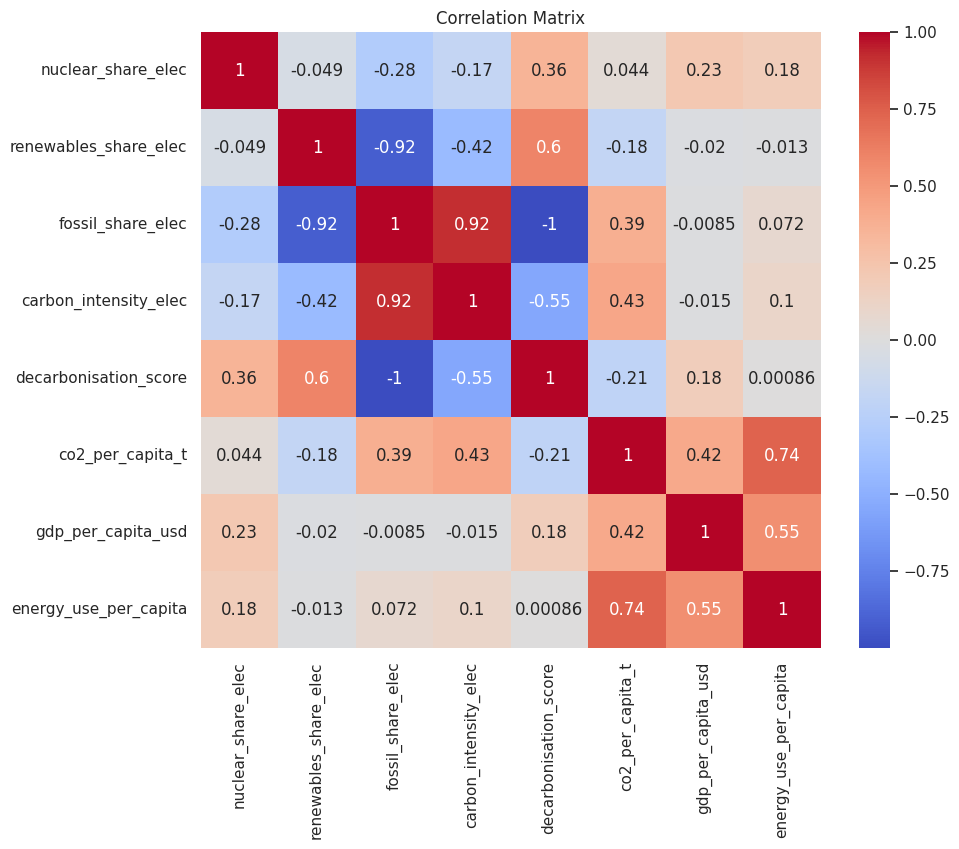

In [8]:

plt.figure(figsize=(10,8))
corr_cols = [
    "nuclear_share_elec",
    "renewables_share_elec",
    "fossil_share_elec",
    "carbon_intensity_elec",
    "decarbonisation_score",
    "co2_per_capita_t",
    "gdp_per_capita_usd",
    "energy_use_per_capita"
]

corr = df[corr_cols].corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()


### Correlation Insights

Several relationships stand out:

- Higher fossil electricity shares are associated with higher carbon intensity.
- Decarbonisation scores tend to move in the opposite direction of carbon intensity.
- Renewable and nuclear shares generally contribute to lower-carbon electricity systems.
- Economic development variables show weaker direct relationships than energy-mix variables, suggesting that generation structure matters more than income alone.


## Carbon Intensity and Decarbonisation

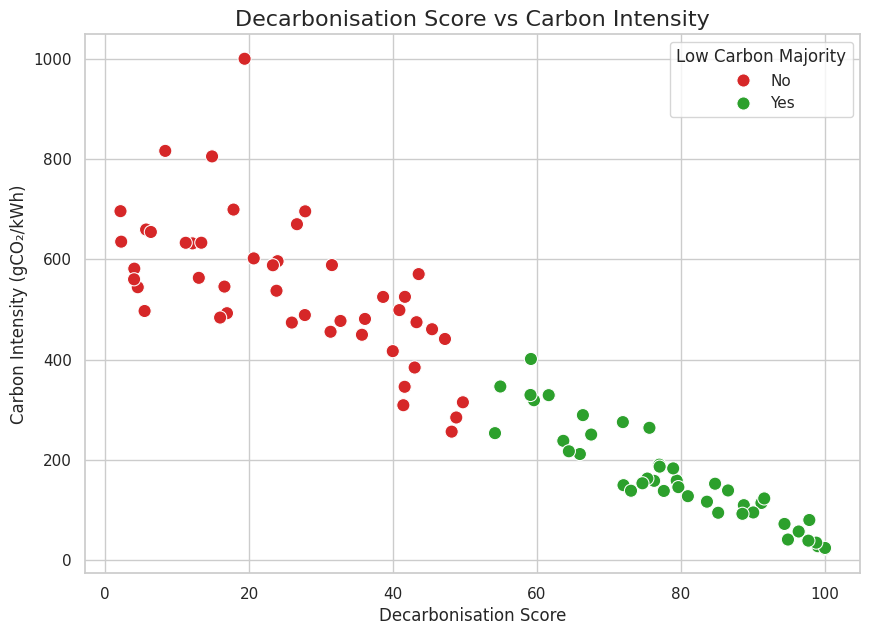

In [9]:
latest_plot = latest.copy()

latest_plot["Low Carbon Majority"] = (
    latest_plot["is_low_carbon_majority"]
    .map({0: "No", 1: "Yes"})
)

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=latest_plot,
    x="decarbonisation_score",
    y="carbon_intensity_elec",
    hue="Low Carbon Majority",
    palette={"No": "#d62728", "Yes": "#2ca02c"},
    s=90,
    alpha=1
)

plt.title("Decarbonisation Score vs Carbon Intensity", fontsize=16)
plt.xlabel("Decarbonisation Score")
plt.ylabel("Carbon Intensity (gCO₂/kWh)")
plt.legend(title="Low Carbon Majority")

plt.show()

### Analysis

The scatter distribution highlights a strong transition pathway.

- Countries with higher decarbonisation scores generally achieve lower electricity carbon intensity.
- Several countries reach low carbon intensity through different combinations of nuclear and renewable generation.
- Large economies appear across multiple regions of the chart, indicating that policy choices and energy resources matter in addition to economic scale.


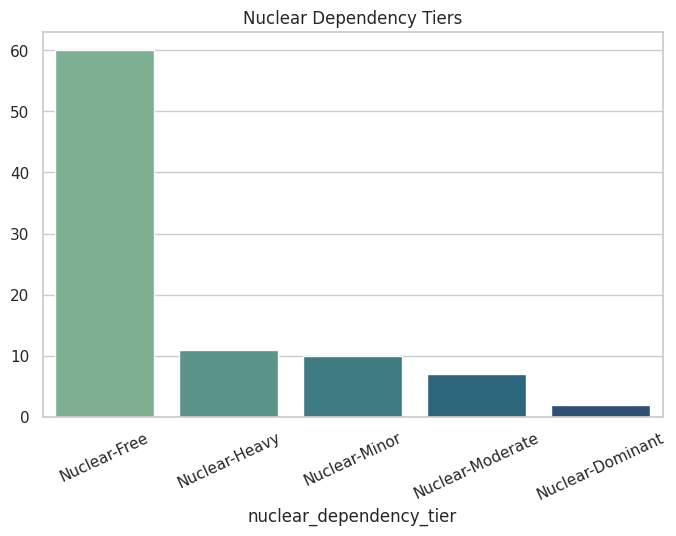

In [10]:

tier_counts = latest["nuclear_dependency_tier"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=tier_counts.index, y=tier_counts.values, palette="crest")
plt.xticks(rotation=25)
plt.title("Nuclear Dependency Tiers")
plt.show()


### Analysis

Most countries remain outside the heavy nuclear category.

- Nuclear-free countries represent the largest group.
- Heavy and dominant nuclear systems are relatively rare.
- Nuclear deployment remains concentrated among a limited set of national energy strategies rather than being globally universal.


## Energy Mix Diversity

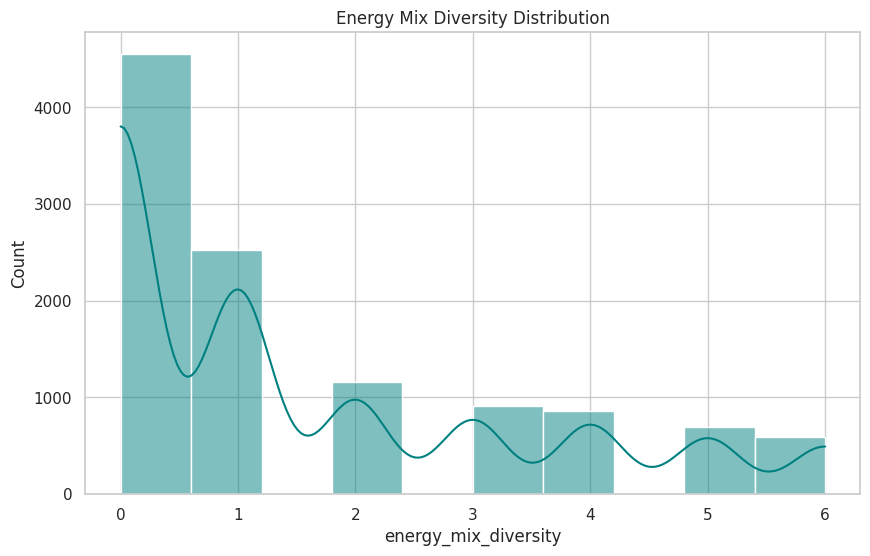

In [11]:

plt.figure(figsize=(10,6))
sns.histplot(df["energy_mix_diversity"], bins=10, kde=True, color="teal")
plt.title("Energy Mix Diversity Distribution")
plt.show()


### Analysis

Energy systems exhibit substantial diversity.

- Many countries rely on multiple generation sources simultaneously.
- Highly diversified energy systems may offer resilience benefits while supporting decarbonisation objectives.
- The distribution suggests that pure single-source electricity systems are uncommon.


## Country Clustering

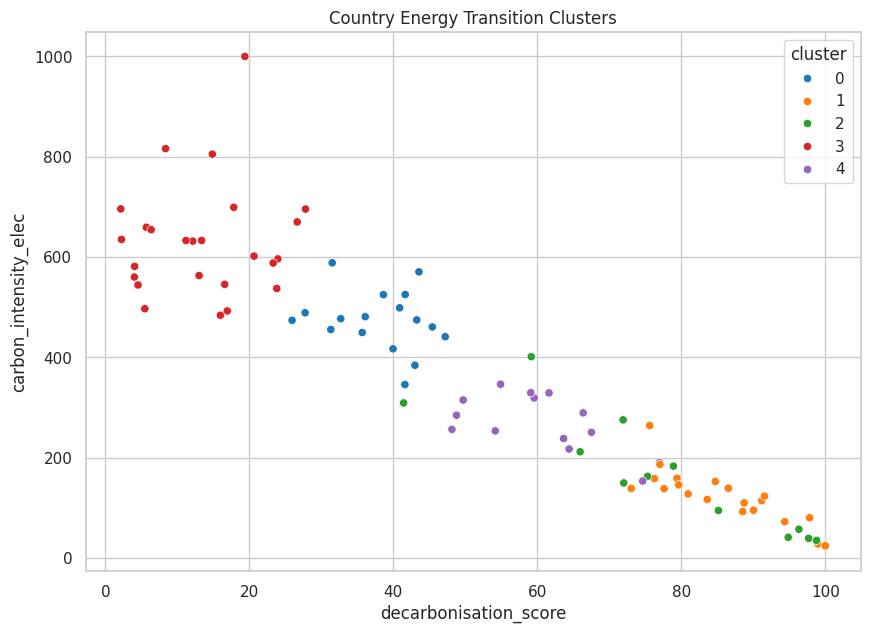

In [12]:

cluster_features = [
    "nuclear_share_elec",
    "renewables_share_elec",
    "fossil_share_elec",
    "carbon_intensity_elec",
    "decarbonisation_score"
]

tmp = latest[cluster_features].copy()

tmp = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(tmp),
    columns=cluster_features
)

scaled = StandardScaler().fit_transform(tmp)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
latest["cluster"] = kmeans.fit_predict(scaled)

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=latest,
    x="decarbonisation_score",
    y="carbon_intensity_elec",
    hue="cluster",
    palette="tab10"
)
plt.title("Country Energy Transition Clusters")
plt.show()


### Clustering Interpretation

The clustering exercise separates countries into distinct transition profiles.

Typical cluster themes include:

1. Fossil-dominated systems with high carbon intensity.
2. Renewable-led systems with improving decarbonisation scores.
3. Nuclear-intensive systems with low operational emissions.
4. Mixed-transition economies balancing several technologies.
5. Emerging transition systems still undergoing structural change.

These clusters provide a useful framework for comparing national energy strategies.


## Predicting Electricity Carbon Intensity

In [13]:
features = [
    "nuclear_share_elec",
    "renewables_share_elec",
    "fossil_share_elec",
    "solar_share_elec",
    "wind_share_elec",
    "energy_mix_diversity",
    "gdp_per_capita_usd",
    "energy_use_per_capita"
]

target = "carbon_intensity_elec"

# Keep only rows where target exists
model_df = df[features + [target]].copy()
model_df = model_df.dropna(subset=[target])

# Features
X = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(model_df[features]),
    columns=features,
    index=model_df.index
)

# Target
y = model_df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Evaluation
print("R2:", round(r2_score(y_test, pred), 4))
print("MAE:", round(mean_absolute_error(y_test, pred), 4))

R2: 0.8627
MAE: 45.5253


### Results

The Random Forest model achieved:

- R² = 0.8627
- MAE ≈ 45.5 gCO₂/kWh

The strong R² indicates that electricity carbon intensity can be explained largely through energy-mix characteristics. Most variation is captured by a relatively small set of generation-share variables.


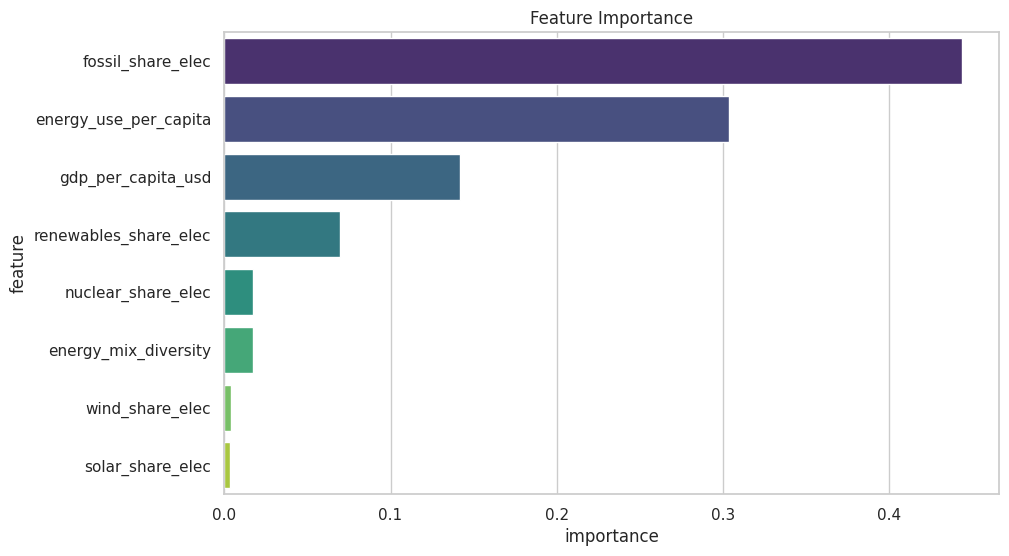

In [14]:

imp = pd.DataFrame({
    "feature":features,
    "importance":model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=imp, y="feature", x="importance", palette="viridis")
plt.title("Feature Importance")
plt.show()


### Feature Importance Analysis

The model identifies fossil electricity share as the dominant predictor.

Key takeaways:

- Fossil generation remains the primary determinant of electricity-sector carbon intensity.
- Energy use per capita contributes meaningful additional explanatory power.
- Renewable shares provide important carbon-reducing signals.
- Nuclear share contributes to prediction quality, although its influence is smaller than the overall fossil-versus-low-carbon balance.



## Explainability

Permutation importance provides a model-agnostic view of which energy system variables drive carbon intensity predictions.


In [15]:

perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42
)

perm_df = pd.DataFrame({
    "feature":features,
    "importance":perm.importances_mean
}).sort_values("importance", ascending=False)

display(perm_df)


,feature,importance
2,fossil_share_elec,0.857932
7,energy_use_per_capita,0.613333
1,renewables_share_elec,0.298922
6,gdp_per_capita_usd,0.276075
5,energy_mix_diversity,0.057828
0,nuclear_share_elec,0.025219
4,wind_share_elec,0.004647
3,solar_share_elec,0.003746


### Explainability Findings

Permutation importance confirms the earlier results.

- Fossil electricity share overwhelmingly drives predictive performance.
- Energy consumption intensity is the second most influential factor.
- Renewable penetration contributes substantially to lower carbon intensity outcomes.
- Solar and wind shares alone add limited incremental information once broader energy-mix indicators are already included.


## Long-Term Evolution of Nuclear Electricity Generation

The final chart smooths annual fluctuations using a five-year rolling average, making long-term structural changes easier to identify.


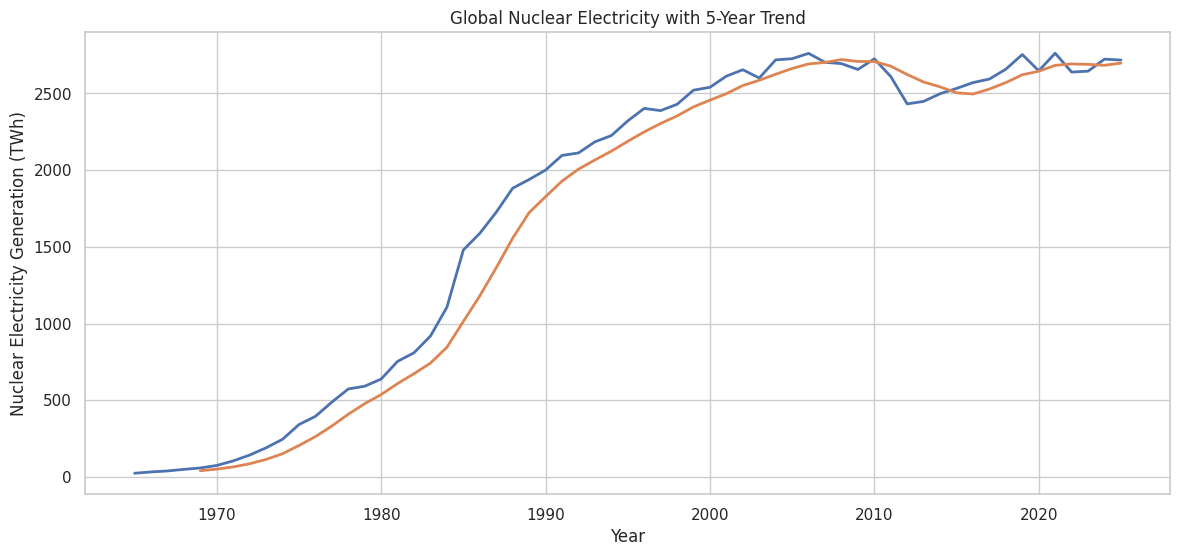

In [16]:

annual = annual.sort_values("year")

annual["rolling_5yr"] = annual["nuclear_electricity"].rolling(5).mean()

plt.figure(figsize=(14,6))
plt.plot(annual["year"], annual["nuclear_electricity"], linewidth=2)
plt.plot(annual["year"], annual["rolling_5yr"], linewidth=2)
plt.title("Global Nuclear Electricity with 5-Year Trend")

plt.xlabel("Year")
plt.ylabel("Nuclear Electricity Generation (TWh)")

plt.show()

## Conclusions

Several conclusions emerge from the analysis:

- Nuclear power remains one of the most important low-carbon electricity sources globally, although deployment is concentrated among a limited number of countries.

- Renewable energy has experienced the strongest growth trajectory in recent decades and increasingly competes with nuclear generation in many markets.

- Carbon intensity is driven primarily by fossil fuel dependence rather than economic development alone.

- Countries achieving the lowest electricity-sector emissions generally combine low-carbon technologies rather than relying on a single solution.

- Machine learning results show that energy-mix variables explain most of the variation in carbon intensity, reinforcing the importance of generation structure in decarbonisation efforts.

- The global transition is not following a single pathway. Countries are reaching lower-carbon electricity systems through different combinations of nuclear, hydro, wind, solar, and other renewable resources.

The evidence suggests that successful decarbonisation strategies are technology-diverse, country-specific, and strongly linked to reducing fossil electricity dependence.
